# Lab 2: From Raw Data to ML-Ready Data
## Data Cleaning & Exploratory Data Analysis — Telco Customer Churn

**Name:** Aftab Asghar

**Roll Number:** 023-24-0234

**GitHub Repository:** https://github.com/aftab-soomro/Machine-Learning

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, NumPy, Pandas, and Matplotlib from previous labs. Each section below states the objective and the questions you must answer — **you decide** which functions/plots are appropriate. Do not just run code without interpreting it: every visualization needs a written observation, and every cleaning decision needs a written justification.
>
> Fill in the empty code cells and the *Answer:* / *Observation:* placeholders directly in this notebook. Do not delete the Markdown headings — they are used for grading.

---

## Setup

Import the libraries you'll need and load the dataset. Use the Telco Customer Churn CSV provided for this lab.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid")

# Load the dataset
df = pd.read_csv("telco_churn.csv")
print("Loaded:", df.shape[0], "rows x", df.shape[1], "columns")


Loaded: 7043 rows x 21 columns


---

## Part 1 — The Business Problem

A telecommunications company is losing customers to competitors — this is called **customer churn**. The company wants to understand which customers are likely to leave, so it can intervene early. Before any model can be built, the raw data must be understood, audited for quality issues, and explored.

**Tasks**
1. In 2–3 sentences, state the business problem in your own words, and propose what the target variable likely is.
2. List 5 columns you expect to be useful predictors of churn, and 2 columns you expect to be useless as predictors — justify each choice in one line.
3. Write down 2 questions you personally want this data to answer about customers who churn.

**Answer 1:**
The company is losing customers to competitors and wants to know *which* customers are likely to leave, early enough to act. As a data problem this is a **binary classification** task: for each customer, predict whether they will churn or not. The target variable is **`Churn`** (Yes / No). One row = one customer's current account snapshot.

**Answer 2:**

*Five columns I expect to be useful:*
- `Contract` — a month-to-month customer can walk away any time, a two-year customer cannot.
- `tenure` — how long someone has already stayed is usually the strongest signal of whether they will keep staying.
- `MonthlyCharges` — a high bill gives a customer a concrete reason to shop around.
- `InternetService` — service type is a proxy for both price and service quality.
- `TechSupport` — customers left to solve their own problems are more likely to give up on the provider.

*Two columns I expect to be useless:*
- `customerID` — a random unique code; it identifies a customer but says nothing about their behaviour.
- `gender` — there is no reason to expect men and women to churn at different rates for a telecom service.

**Answer 3:**
1. Do customers leave mostly in their first few months, or is churn spread evenly across the whole customer lifetime?
2. Are customers leaving because of price, or because of the service/contract they are on?

---

## Part 2 — Exploring the Dataset Structure

Before cleaning or analyzing anything, get an accurate picture of the dataset's shape and contents. Running a command is not the same as understanding its output — you must interpret what you see.

*Concepts/functions you may find useful:* `df.shape`, `df.columns`, `df.dtypes`, `df.info()`, `df.head()`, `df.sample(n)`, `df[col].unique()`, `df[col].nunique()`, `df.describe(include='all')`

**Tasks**
4. How many customers and how many features are in this dataset? List the numerical features and the categorical features separately.
5. Identify any column(s) that are simply identifiers rather than predictive features, and any column(s) whose data type looks wrong for what it represents.
6. Pick 3 categorical columns and report their unique values — do any contain unexpected or inconsistent categories?

In [2]:
# Task 4 — dataset shape, column names, data types
print("Shape:", df.shape)
print(f"{df.shape[0]} customers, {df.shape[1]} columns\n")

df.info()

# Split the columns by what pandas *thinks* they are
numerical = df.select_dtypes(include=np.number).columns.tolist()
categorical = [c for c in df.columns if c not in numerical]

print("\nNumerical   (%d):" % len(numerical), numerical)
print("Categorical (%d):" % len(categorical), categorical)


Shape: (7043, 21)
7043 customers, 21 columns

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  Paperle

In [3]:
# Task 5 — identify identifier columns / wrong data types

# An identifier is (nearly) unique for every row
print("Columns that look like identifiers:")
for col in df.columns:
    n = df[col].nunique()
    if n > len(df) * 0.9:
        print(f"  {col}: {n} unique values across {len(df)} rows")

print("\nColumns whose dtype looks wrong for what they represent:")

# TotalCharges is money, so it should be numeric
print(f"  TotalCharges -> dtype is {df['TotalCharges'].dtype}, but it holds money")
coerced = pd.to_numeric(df["TotalCharges"], errors="coerce")
print(f"     {coerced.isna().sum()} values cannot be parsed as a number (that is why it stayed text)")

# SeniorCitizen is numeric, but it is really a yes/no flag
print(f"  SeniorCitizen -> dtype is {df['SeniorCitizen'].dtype}, values are {df['SeniorCitizen'].unique()}")
print("     stored as 0/1, but it is a category, not a quantity you can average meaningfully")


Columns that look like identifiers:
  customerID: 7043 unique values across 7043 rows
  TotalCharges: 6531 unique values across 7043 rows

Columns whose dtype looks wrong for what they represent:
  TotalCharges -> dtype is str, but it holds money
     11 values cannot be parsed as a number (that is why it stayed text)
  SeniorCitizen -> dtype is int64, values are [0 1]
     stored as 0/1, but it is a category, not a quantity you can average meaningfully


In [4]:
# Task 6 — unique values in 3 categorical columns
for col in ["MultipleLines", "OnlineSecurity", "PaymentMethod"]:
    print(f"=== {col} — {df[col].nunique()} unique values ===")
    print(df[col].value_counts())
    print()


=== MultipleLines — 3 unique values ===
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

=== OnlineSecurity — 3 unique values ===
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

=== PaymentMethod — 4 unique values ===
PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64



**Observations (Part 2):**

- The dataset has **7,043 customers and 21 columns**.
- Pandas reads only **3 columns as numerical**: `SeniorCitizen`, `tenure`, `MonthlyCharges`. The other 18 come in as text.
- **`customerID` is an identifier, not a feature** — it has 7,043 unique values across 7,043 rows, so it is unique for every single customer.
- **Two columns have the wrong data type for what they represent:**
  - `TotalCharges` holds money but was read as **text**, because at least one value cannot be parsed as a number.
  - `SeniorCitizen` is stored as **int64 (0/1)** but it is really a yes/no category — averaging it would be meaningless.
- Checking three categorical columns showed **nested categories** that are easy to miss:
  - `MultipleLines` → `No` (3,390), `Yes` (2,971), **`No phone service`** (682)
  - `OnlineSecurity` → `No` (3,498), `Yes` (2,019), **`No internet service`** (1,526)
  - `PaymentMethod` → 4 clean categories, `Electronic check` the largest at 2,365

  The `No phone service` / `No internet service` labels are not inconsistent spellings — they carry a *different meaning* from plain `No`. "No" means the customer could have the add-on but declined it; "No internet service" means the add-on was never available to them. That distinction matters when these columns are encoded later.

---

## Part 3 — Investigating Data Quality

A dataset can look clean at a glance and still hide serious problems. You must actively search for missing values, duplicates, and suspicious values rather than assume there are none.

*Concepts/functions you may find useful:* `df.isnull().sum()`, `df.isnull().mean()*100`, `df.duplicated().sum()`, `df['id_col'].duplicated().sum()`, `df[col].value_counts()`

**Tasks**
7. Report missing values as both a count and a percentage per column. Which missing-value problems do you think require action, and which don't? Justify your reasoning.
8. Check for duplicate rows and duplicate customer IDs separately — are they the same issue or different issues?
9. Find at least one column with a suspicious, invalid, or inconsistently formatted value, and describe how you found it.

In [5]:
# Task 7 — missing values: count and percentage per column
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_pct": (df.isnull().mean() * 100).round(2),
})
print(missing)
print("\nTotal NaN reported by isnull():", int(df.isnull().sum().sum()))

# isnull() is not the whole story — a blank string is "present" as far as pandas is concerned
print("\nBlank / whitespace-only values that isnull() does NOT catch:")
found = False
for col in df.columns:
    s = df[col].astype("string")
    n = int((s.str.strip() == "").fillna(False).sum())
    if n:
        found = True
        print(f"  {col}: {n} rows ({n / len(df) * 100:.2f}%)")
if not found:
    print("  none")


                  missing_count  missing_pct
customerID                    0          0.0
gender                        0          0.0
SeniorCitizen                 0          0.0
Partner                       0          0.0
Dependents                    0          0.0
tenure                        0          0.0
PhoneService                  0          0.0
MultipleLines                 0          0.0
InternetService               0          0.0
OnlineSecurity                0          0.0
OnlineBackup                  0          0.0
DeviceProtection              0          0.0
TechSupport                   0          0.0
StreamingTV                   0          0.0
StreamingMovies               0          0.0
Contract                      0          0.0
PaperlessBilling              0          0.0
PaymentMethod                 0          0.0
MonthlyCharges                0          0.0
TotalCharges                  0          0.0
Churn                         0          0.0

Total NaN

In [6]:
# Task 8 — duplicate rows vs duplicate IDs
print("Fully duplicated rows  :", df.duplicated().sum())
print("Duplicated customerIDs :", df["customerID"].duplicated().sum())
print("Unique customerIDs     :", df["customerID"].nunique(), "out of", len(df), "rows")


Fully duplicated rows  : 0
Duplicated customerIDs : 0
Unique customerIDs     : 7043 out of 7043 rows


In [7]:
# Task 9 — investigate a suspicious / invalid value

# How it was found: TotalCharges holds money but pandas kept it as text,
# which means at least one value is not parseable as a number.
bad = pd.to_numeric(df["TotalCharges"], errors="coerce").isna()

print("Rows where TotalCharges is not a valid number:", int(bad.sum()))
print("The raw offending value(s):", repr(df.loc[bad, "TotalCharges"].unique().tolist()))
print()
print("What do those rows look like?")
print(df.loc[bad, ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Contract", "Churn"]])
print()
print("tenure values among these rows:", sorted(df.loc[bad, "tenure"].unique().tolist()))
print("Churn values among these rows :", df.loc[bad, "Churn"].unique().tolist())


Rows where TotalCharges is not a valid number: 11
The raw offending value(s): [' ']

What do those rows look like?
      customerID  tenure  MonthlyCharges TotalCharges  Contract Churn
488   4472-LVYGI       0           52.55               Two year    No
753   3115-CZMZD       0           20.25               Two year    No
936   5709-LVOEQ       0           80.85               Two year    No
1082  4367-NUYAO       0           25.75               Two year    No
1340  1371-DWPAZ       0           56.05               Two year    No
3331  7644-OMVMY       0           19.85               Two year    No
3826  3213-VVOLG       0           25.35               Two year    No
4380  2520-SGTTA       0           20.00               Two year    No
5218  2923-ARZLG       0           19.70               One year    No
6670  4075-WKNIU       0           73.35               Two year    No
6754  2775-SEFEE       0           61.90               Two year    No

tenure values among these rows: [0]
Churn va

**Answer 7 (which missing-value problems need action, and why):**

`isnull()` reports **0 missing values in every one of the 21 columns** — the dataset looks perfectly clean at first glance. That conclusion is wrong.

`TotalCharges` contains **11 rows (0.16%) holding a blank space `" "`**. Pandas treats a blank string as a *present* text value, so `isnull()` never flags it. This is exactly the kind of problem that survives a careless audit.

This one **does require action**, not because 11 rows out of 7,043 would distort statistics, but because the blank is what forced the whole column to stay as text. Until it is fixed, `TotalCharges` cannot be used in any numerical calculation at all — no mean, no correlation, no model input. So the issue is about the *column's usability*, not about the 11 rows themselves.

Nothing else needs action: there are no true NaNs anywhere and no other blank-like values in any column.

**Answer 8 (duplicate rows vs duplicate IDs — same issue or different?):**

Both come back clean here: **0 fully duplicated rows** and **0 duplicated customerIDs** (7,043 unique IDs across 7,043 rows).

They are **different problems** and must be checked separately:
- A **duplicated row** means the exact same record was recorded twice — usually a data-loading or export error. Safe to drop.
- A **duplicated customerID** with *different* values in the other columns is worse: it means one customer appears twice with conflicting information. You cannot just drop one — you have to decide which version is true.

Checking only `df.duplicated()` would completely miss the second case, which is the more damaging of the two.

**Answer 9 (suspicious value found and how):**

**How I found it:** I did not look for it directly. `TotalCharges` is money, so it should have loaded as a float — but `df.dtypes` showed it as text. That mismatch is the clue: pandas only falls back to text when *something* in the column will not parse. Running `pd.to_numeric(df['TotalCharges'], errors='coerce')` and counting the NaNs pinned it down to **11 rows**, and printing the raw values showed a single offender: `' '` (a blank space).

**What makes it interesting:** inspecting those 11 rows revealed a pattern that is not random at all — **every one of them has `tenure = 0`**, and **every one of them has `Churn = No`**. These are brand-new customers who signed up but have not been billed a single cycle yet. So the blank is not corrupt data — it is the dataset's way of representing "no charges have accrued yet." That distinction changes what the correct fix is (see Part 4).

---

## Part 4 — Data Cleaning Decisions

Cleaning is a series of justified decisions, not a fixed recipe. For every issue you fix, you must be able to explain why you chose that method over an alternative.

*Concepts/functions you may find useful:* `pd.to_numeric(s, errors='coerce')`, `df.fillna(value)`, `df.dropna()`, `df.drop_duplicates()`, `df[col].str.strip()`, `df.astype(dtype)`

**Tasks**
10. For every data-quality issue you found in Part 3, record: Problem → Decision → Method Used → Reason.
11. Apply your cleaning decisions to produce an intermediate cleaned dataframe, and confirm (with code output) that each issue is actually resolved.

**Task 10 — Cleaning Decision Log**

| Problem | Decision | Method Used | Reason |
|---|---|---|---|
| `TotalCharges` is money but stored as text, because 11 rows contain a blank `" "` | Convert the column to numeric and let the blanks become NaN | `pd.to_numeric(df['TotalCharges'], errors='coerce')` | The column is unusable for any numeric work while it stays as text. `errors='coerce'` turns the unparseable blanks into proper NaN instead of silently dropping rows. |
| The 11 resulting NaNs in `TotalCharges` | Fill with **0.0**, not the mean or median | `.fillna(0.0)` | All 11 rows have `tenure = 0` — these customers have never been billed, so their true lifetime charge *is* zero. Filling with the median (~1,397) would invent revenue that never existed and would break the near-perfect `tenure × MonthlyCharges ≈ TotalCharges` relationship. Dropping the rows would throw away 11 valid new customers. |
| `SeniorCitizen` stored as int64 `0/1`, implying it is a quantity | Map to the text categories `No` / `Yes` | `.map({0: 'No', 1: 'Yes'})` | It is a yes/no flag, not a number. Leaving it numeric lets `describe()` and `corr()` treat it as a measurable amount, and it would be wrongly grouped with the real numerical features. Mapping it makes it consistent with every other yes/no column in the dataset. |
| Possible stray leading/trailing whitespace in text columns | Strip whitespace from all 17 text columns | `.str.strip()` on every string column | `" Yes"` and `"Yes"` become two separate categories during encoding, silently splitting a group in half. Cheap to do, and it guarantees the problem cannot exist rather than assuming it does not. |
| `customerID` is a unique identifier, not a predictor | Drop it when building `clean_df` (Part 11) | `.drop(columns=['customerID'])` | 7,043 unique values across 7,043 rows. It carries no information about behaviour, and a model given it can memorise individual customers instead of learning a pattern. |

*Not cleaned, deliberately:* no rows were dropped for duplicates (there are none), and the `No internet service` / `No phone service` categories were left as-is because they carry a real meaning that is different from plain `No`.

In [8]:
# Task 11 — apply your cleaning decisions here
clean = df.copy()

# Decision 1: TotalCharges text -> numeric. Blank strings become NaN.
clean["TotalCharges"] = pd.to_numeric(clean["TotalCharges"], errors="coerce")

# Decision 2: those NaNs all belong to tenure == 0 customers (never billed yet),
# so 0.0 is the factually correct value — not the median, which would invent charges.
clean["TotalCharges"] = clean["TotalCharges"].fillna(0.0)

# Decision 3: SeniorCitizen is a yes/no flag, not a quantity — make that explicit.
clean["SeniorCitizen"] = clean["SeniorCitizen"].map({0: "No", 1: "Yes"})

# Decision 4: strip stray whitespace from every text column.
text_cols = [c for c in clean.columns if pd.api.types.is_string_dtype(clean[c])]
for col in text_cols:
    clean[col] = clean[col].str.strip()

print("Cleaning applied to", len(clean), "rows.")
print("Text columns stripped:", len(text_cols))


Cleaning applied to 7043 rows.
Text columns stripped: 18


In [9]:
# Task 11 (continued) — confirm each issue is resolved
print("TotalCharges dtype now  :", clean["TotalCharges"].dtype)
print("TotalCharges NaN now    :", int(clean["TotalCharges"].isna().sum()))

blanks = sum(
    int((clean[c].astype("string").str.strip() == "").fillna(False).sum())
    for c in clean.columns
)
print("Blank-like strings now  :", blanks)
print("Duplicated rows         :", clean.duplicated().sum())
print("Duplicated customerIDs  :", clean["customerID"].duplicated().sum())
print("SeniorCitizen values    :", clean["SeniorCitizen"].unique().tolist())
print()
print("The 11 previously-blank rows, after cleaning:")
print(clean.loc[bad, ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]])


TotalCharges dtype now  : float64
TotalCharges NaN now    : 0


Blank-like strings now  : 0


Duplicated rows         : 0
Duplicated customerIDs  : 0
SeniorCitizen values    : ['No', 'Yes']

The 11 previously-blank rows, after cleaning:
      customerID  tenure  MonthlyCharges  TotalCharges
488   4472-LVYGI       0           52.55           0.0
753   3115-CZMZD       0           20.25           0.0
936   5709-LVOEQ       0           80.85           0.0
1082  4367-NUYAO       0           25.75           0.0
1340  1371-DWPAZ       0           56.05           0.0
3331  7644-OMVMY       0           19.85           0.0
3826  3213-VVOLG       0           25.35           0.0
4380  2520-SGTTA       0           20.00           0.0
5218  2923-ARZLG       0           19.70           0.0
6670  4075-WKNIU       0           73.35           0.0
6754  2775-SEFEE       0           61.90           0.0


---

## Part 5 — Univariate EDA

Look at individual variables in isolation before looking at relationships. Every chart must be followed by a written interpretation — a graph with no explanation earns no credit.

*Concepts/functions you may find useful:* `df[col].plot(kind='hist')` / `plt.hist()`, `df.boxplot(column=col)`, `df[col].value_counts().plot(kind='bar')`

**Tasks**
12. Visualize the distribution of at least 2 numerical features and 2 categorical features. For each chart, write 1–2 sentences on what you learned.
13. Do any numerical features show outliers or a skewed distribution? What might explain this?

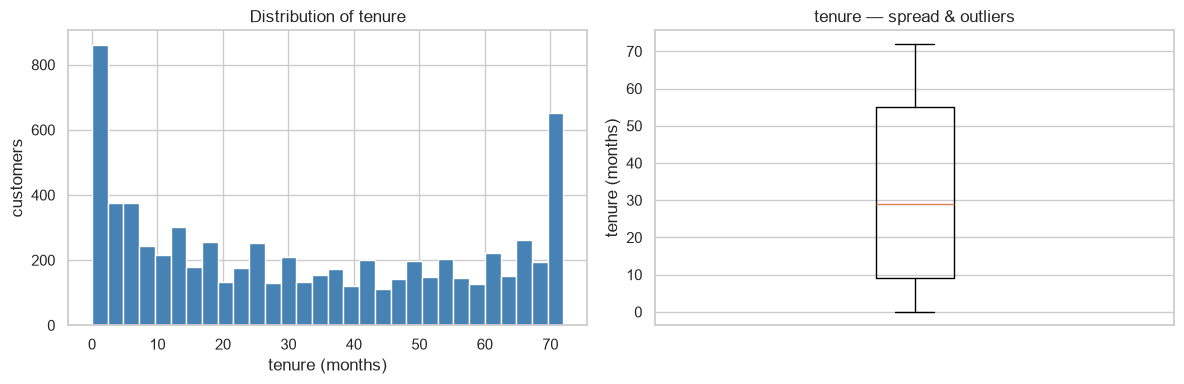

count    7043.00
mean       32.37
std        24.56
min         0.00
25%         9.00
50%        29.00
75%        55.00
max        72.00
Name: tenure, dtype: float64

skewness: 0.24
customers with tenure == 0 : 11
customers with tenure == 72: 362


In [10]:
# Task 12 — numerical feature 1: distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(clean["tenure"], bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution of tenure")
axes[0].set_xlabel("tenure (months)")
axes[0].set_ylabel("customers")

axes[1].boxplot(clean["tenure"])
axes[1].set_title("tenure — spread & outliers")
axes[1].set_ylabel("tenure (months)")
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

print(clean["tenure"].describe().round(2))
print("\nskewness:", round(clean["tenure"].skew(), 3))
print("customers with tenure == 0 :", int((clean["tenure"] == 0).sum()))
print("customers with tenure == 72:", int((clean["tenure"] == 72).sum()))


**Observation:** `tenure` is **not** a normal bell curve — it is **U-shaped (bathtub)**. There are two large spikes at the opposite ends: **11 customers at 0 months** and **362 customers at 72 months** (the maximum), with a flatter middle. The median is 29 months against a mean of 32.37, and skewness is only **0.24**, i.e. almost symmetric — which shows why skewness alone is a poor summary and the histogram had to be looked at. The boxplot flags **no outliers**, because 0 and 72 are simply the natural limits of the recorded range.

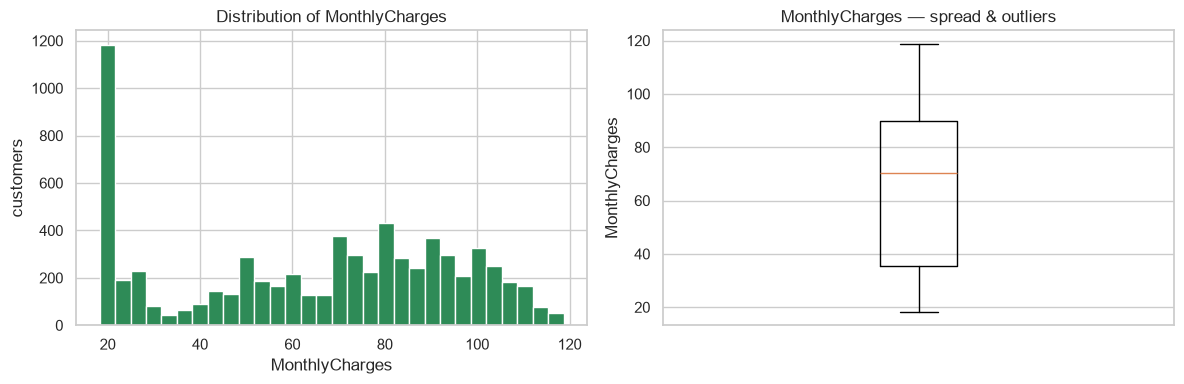

count    7043.00
mean       64.76
std        30.09
min        18.25
25%        35.50
50%        70.35
75%        89.85
max       118.75
Name: MonthlyCharges, dtype: float64

skewness: -0.221


In [11]:
# Task 12 — numerical feature 2: distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(clean["MonthlyCharges"], bins=30, color="seagreen", edgecolor="white")
axes[0].set_title("Distribution of MonthlyCharges")
axes[0].set_xlabel("MonthlyCharges")
axes[0].set_ylabel("customers")

axes[1].boxplot(clean["MonthlyCharges"])
axes[1].set_title("MonthlyCharges — spread & outliers")
axes[1].set_ylabel("MonthlyCharges")
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

print(clean["MonthlyCharges"].describe().round(2))
print("\nskewness:", round(clean["MonthlyCharges"].skew(), 3))


**Observation:** `MonthlyCharges` is **bimodal**, not bell-shaped. There is a tall cluster near the bottom of the range (around \$20, customers on a phone-only or minimal plan) and a much broader, heavier group spread between roughly \$70 and \$110. The dip in between means very few customers sit at mid-range prices. The median (**70.35**) sits *above* the mean (**64.76**) and skewness is slightly negative (**−0.221**), both pulled down by that cheap-plan cluster. Range is \$18.25 to \$118.75, and the boxplot shows **no outliers** — the spread is genuine product tiering, not bad data.

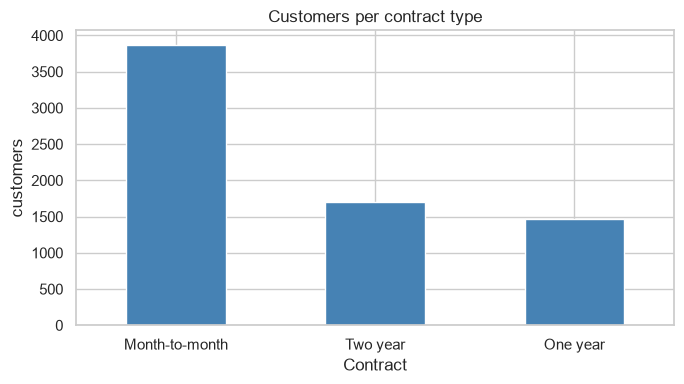

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

Contract
Month-to-month    55.0 %
Two year          24.1 %
One year          20.9 %
Name: proportion, dtype: str


In [12]:
# Task 12 — categorical feature 1: distribution plot
counts = clean["Contract"].value_counts()

ax = counts.plot(kind="bar", color="steelblue", figsize=(7, 4))
ax.set_title("Customers per contract type")
ax.set_xlabel("Contract")
ax.set_ylabel("customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(counts)
print()
print((clean["Contract"].value_counts(normalize=True) * 100).round(1).astype(str) + " %")


**Observation:** Contract types are heavily unbalanced toward the short end. **Month-to-month dominates at 3,875 customers (55.0%)** — more than the other two types combined — followed by Two year (1,695 / 24.1%) and One year (1,473 / 20.9%). More than half the customer base is therefore free to leave at any time with no penalty, which is already a warning sign for a company worried about churn, before any churn numbers are even looked at.

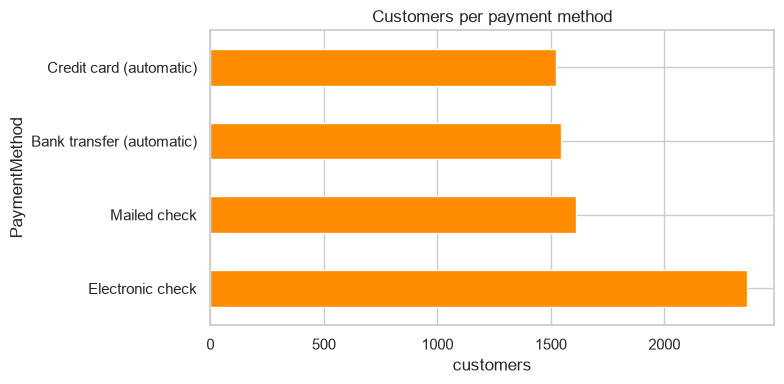

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

PaymentMethod
Electronic check             33.6 %
Mailed check                 22.9 %
Bank transfer (automatic)    21.9 %
Credit card (automatic)      21.6 %
Name: proportion, dtype: str


In [13]:
# Task 12 — categorical feature 2: distribution plot
counts = clean["PaymentMethod"].value_counts()

ax = counts.plot(kind="barh", color="darkorange", figsize=(8, 4))
ax.set_title("Customers per payment method")
ax.set_xlabel("customers")
plt.tight_layout()
plt.show()

print(counts)
print()
print((clean["PaymentMethod"].value_counts(normalize=True) * 100).round(1).astype(str) + " %")


**Observation:** Payment methods are fairly evenly split across three of the four options — Mailed check (1,612 / 22.9%), Bank transfer (1,544 / 21.9%) and Credit card (1,522 / 21.6%) are almost identical in size. **Electronic check stands out as the largest at 2,365 customers (33.6%)**, taking a third of the base on its own. Notably, the two *automatic* methods (bank transfer + credit card) together account for only 43.5% — most customers are still paying manually each month.

**Answer 13 (outliers / skew and possible explanation):**

**Neither numerical feature has real outliers.** Both boxplots came back clean, and both columns are bounded by the business itself: `tenure` cannot exceed 72 months because that is how long the company has been tracking these customers, and `MonthlyCharges` is capped by the most expensive bundle on sale (\$118.75).

**Neither is strongly skewed either** — 0.24 for `tenure`, −0.221 for `MonthlyCharges`, both close to 0. But that number is misleading, and the histograms show why: skewness measures *asymmetry*, not *shape*. Both distributions are far from normal, just symmetrically so.

**What explains the shapes:**
- `tenure` is U-shaped because two different populations are mixed in one column: a steady stream of **new sign-ups** at the left, and a large block of **long-term loyal customers** who have been there since the beginning piled up at the 72-month ceiling. The thin middle means customers tend to either leave early or stay for good.
- `MonthlyCharges` is bimodal because of **product tiering**, not customer behaviour: the ~\$20 cluster is phone-only/no-internet customers, and the \$70–110 group is customers with internet plus add-on services. There is simply no product priced in between.

`TotalCharges` would be the genuinely right-skewed column of the three, since it compounds tenure and monthly charges together — most customers have accumulated a little, a few have accumulated a lot.

---

## Part 6 — Target Variable Analysis

The `Churn` column is what you will eventually predict. Before Lab 3, you need to understand its distribution — this has direct consequences for how a model should later be trained and evaluated.

*Concepts/functions you may find useful:* `df['Churn'].value_counts()`, `df['Churn'].value_counts(normalize=True)`

**Tasks**
14. Report the number and percentage of churned vs. non-churned customers. Is the target balanced or imbalanced?
15. In 2–3 sentences, explain why class imbalance might matter when a classification model is trained later — do not describe how to fix it, just why it matters.

       count  percent
Churn                
No      5174    73.46
Yes     1869    26.54


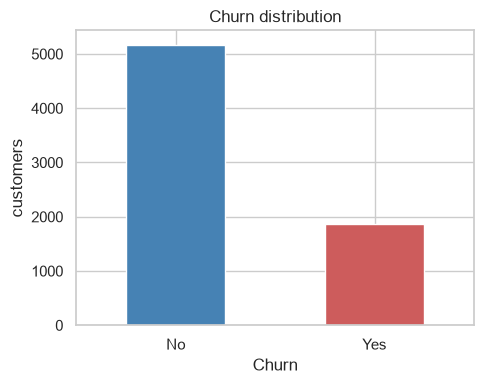


Ratio -> 2.77 : 1  (No : Yes)
A model that always predicts 'No' would already be 73.46% accurate.


In [14]:
# Task 14 — churn counts and percentages
counts = clean["Churn"].value_counts()
pct = (clean["Churn"].value_counts(normalize=True) * 100).round(2)
print(pd.DataFrame({"count": counts, "percent": pct}))

ax = counts.plot(kind="bar", color=["steelblue", "indianred"], figsize=(5, 4))
ax.set_title("Churn distribution")
ax.set_ylabel("customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"\nRatio -> {counts['No'] / counts['Yes']:.2f} : 1  (No : Yes)")
print(f"A model that always predicts 'No' would already be {pct['No']:.2f}% accurate.")


**Answer 14 (balanced or imbalanced?):**

The target is **imbalanced**:

| Churn | Count | Percent |
|---|---|---|
| No | 5,174 | **73.46%** |
| Yes | 1,869 | **26.54%** |

That is a ratio of roughly **2.77 : 1** in favour of the majority class. It is a moderate imbalance — not extreme like fraud detection at 1:1000 — but far from the 50/50 split that accuracy quietly assumes.

**Answer 15 (why imbalance might matter later):**

The class we actually care about is the **smaller** one. A model can score **73.46% accuracy by predicting "No" for every single customer** and never identifying one churner — a useless model with a respectable-looking score. Accuracy is therefore the wrong metric here, because it rewards the majority class for free.

Training is affected too: most algorithms minimise total error, so they will happily sacrifice the 1,869 churners to get the 5,174 stayers right. The result is a model that looks fine overall but has poor **recall** on churn — and missing a customer who is about to leave is exactly the mistake this project exists to prevent. Precision, recall, F1 and the confusion matrix will show what accuracy hides.

---

## Part 7 — Bivariate Analysis: Features vs. Churn

Now connect individual features to the target. You choose the appropriate visualization or summary for each feature type — a categorical feature is not explored the same way as a numerical one.

*Concepts/functions you may find useful:* `pd.crosstab(df[col], df['Churn'], normalize='index')`, `df.groupby(col)['Churn']...`, `sns.boxplot(x='Churn', y=col, data=df)`

**Tasks**
16. Investigate at least 2 categorical features (e.g. Contract, InternetService, PaymentMethod) against Churn. For each, record: Observation / Evidence / Possible Explanation.
17. Investigate at least 2 numerical features (e.g. tenure, MonthlyCharges) against Churn using the same Observation / Evidence / Possible Explanation format.

Churn rate (%) by Contract:
Churn             No   Yes
Contract                  
Month-to-month  57.3  42.7
One year        88.7  11.3
Two year        97.2   2.8

Raw counts:
Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48


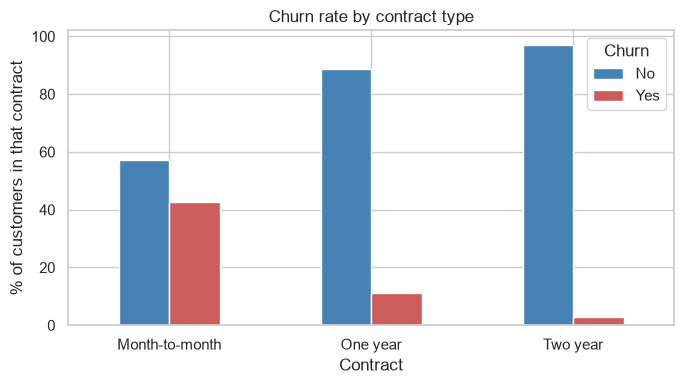

In [15]:
# Task 16 — categorical feature 1 vs Churn
ct = pd.crosstab(clean["Contract"], clean["Churn"], normalize="index") * 100
print("Churn rate (%) by Contract:")
print(ct.round(1))
print()
print("Raw counts:")
print(pd.crosstab(clean["Contract"], clean["Churn"]))

ct.plot(kind="bar", figsize=(7, 4), color=["steelblue", "indianred"])
plt.title("Churn rate by contract type")
plt.ylabel("% of customers in that contract")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()


**Observation:** Churn rate falls sharply and consistently as contract length increases — this is the strongest categorical relationship in the whole dataset.

**Evidence:** Month-to-month **42.7%** (1,655 of 3,875) → One year **11.3%** (166 of 1,473) → Two year **2.8%** (48 of 1,695). A month-to-month customer is roughly **15 times** more likely to churn than a two-year customer. And because month-to-month is also the *largest* group (55% of all customers), it contributes 1,655 of the 1,869 total churners — **89% of all churn comes from this one segment**.

**Possible Explanation:** Two forces point the same way. First, a contract is a **barrier to leaving** — month-to-month customers can walk away costlessly, while long-contract customers face lock-in or an exit fee. Second, there is **self-selection**: a customer who was already unsure about staying chooses the flexible plan in the first place, so the group starts out less committed. The contract does not only *prevent* churn, it also *attracts* the people least likely to churn.

Churn rate (%) by InternetService:
Churn              No   Yes
InternetService            
DSL              81.0  19.0
Fiber optic      58.1  41.9
No               92.6   7.4

Raw counts:


Churn              No   Yes
InternetService            
DSL              1962   459
Fiber optic      1799  1297
No               1413   113


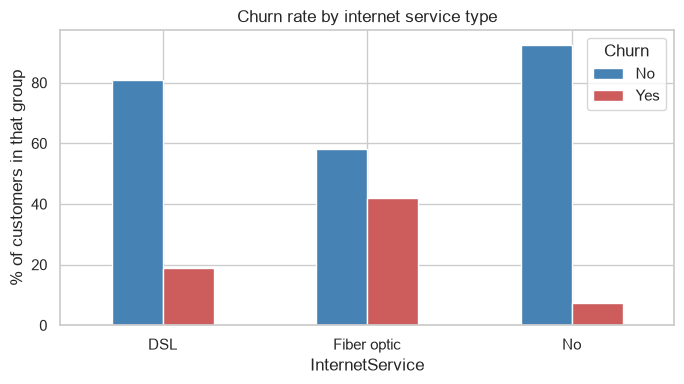

In [16]:
# Task 16 — categorical feature 2 vs Churn
ct = pd.crosstab(clean["InternetService"], clean["Churn"], normalize="index") * 100
print("Churn rate (%) by InternetService:")
print(ct.round(1))
print()
print("Raw counts:")
print(pd.crosstab(clean["InternetService"], clean["Churn"]))

ct.plot(kind="bar", figsize=(7, 4), color=["steelblue", "indianred"])
plt.title("Churn rate by internet service type")
plt.ylabel("% of customers in that group")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()


**Observation:** Fiber optic customers churn at more than double the rate of DSL customers, and customers with no internet at all are by far the most loyal.

**Evidence:** Fiber optic **41.9%** (1,297 of 3,096) → DSL **19.0%** (459 of 2,421) → No internet service **7.4%** (113 of 1,526).

**Possible Explanation:** This is the counter-intuitive result in the dataset — the *premium* product has the *worst* retention. A few explanations are plausible and this data alone cannot separate them. Fiber is the expensive tier, so those customers carry the highest bills and have the most to gain by switching. It is also the most competitive part of the market, so rival offers are easiest to find. And a premium price sets a premium expectation, so any reliability problem feels worse than the same problem on a cheap plan. The "No internet service" group is the mirror image: they are typically phone-only customers on ~\$20 bills with little reason and little incentive to move.

tenure summary by churn status:
        count   mean    std  min   25%   50%   75%   max
Churn                                                   
No     5174.0  37.57  24.11  0.0  15.0  38.0  61.0  72.0
Yes    1869.0  17.98  19.53  1.0   2.0  10.0  29.0  72.0


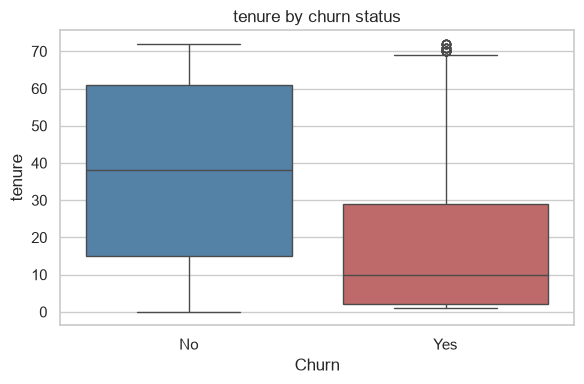


Median tenure — stayed: 38.0 months, churned: 10.0 months


In [17]:
# Task 17 — numerical feature 1 vs Churn
print("tenure summary by churn status:")
print(clean.groupby("Churn")["tenure"].describe().round(2))

plt.figure(figsize=(6, 4))
sns.boxplot(data=clean, x="Churn", y="tenure", hue="Churn",
            palette=["steelblue", "indianred"], legend=False)
plt.title("tenure by churn status")
plt.tight_layout()
plt.show()

median_no = clean.loc[clean["Churn"] == "No", "tenure"].median()
median_yes = clean.loc[clean["Churn"] == "Yes", "tenure"].median()
print(f"\nMedian tenure — stayed: {median_no} months, churned: {median_yes} months")


**Observation:** Churners are overwhelmingly **new** customers. The two groups have almost completely different tenure profiles.

**Evidence:** Median tenure is **38 months for customers who stayed** but only **10 months for customers who churned** — and the mean gap is just as wide (37.57 vs 17.98). The quartiles make it starker: **25% of churners left within 2 months**, and 75% left within 29 months. Cut by tenure band, customers in their **first 12 months churn at 47.4%** (2,186 customers), while those past **60 months churn at just 6.6%** (1,407 customers). `tenure` also has the strongest correlation with churn of any numerical feature (**−0.352**).

**Possible Explanation:** Churn risk is concentrated in the **onboarding window**, not spread evenly across the customer lifetime. New customers have not yet built a habit, have no switching cost, and are still comparing what they bought against what was promised — a bad first experience is enough to lose them. Customers who make it past the first year have effectively self-selected into staying: the service works for them, and inertia takes over. Practically, this says retention effort is worth far more in the first few months than later.

MonthlyCharges summary by churn status:
        count   mean    std    min    25%    50%   75%     max
Churn                                                         
No     5174.0  61.27  31.09  18.25  25.10  64.43  88.4  118.75
Yes    1869.0  74.44  24.67  18.85  56.15  79.65  94.2  118.35


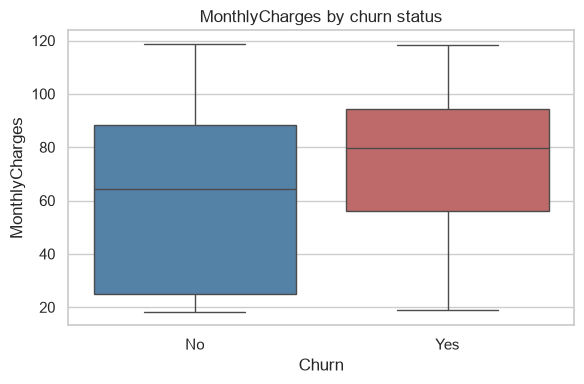


Mean MonthlyCharges — stayed: 61.27, churned: 74.44


In [18]:
# Task 17 — numerical feature 2 vs Churn
print("MonthlyCharges summary by churn status:")
print(clean.groupby("Churn")["MonthlyCharges"].describe().round(2))

plt.figure(figsize=(6, 4))
sns.boxplot(data=clean, x="Churn", y="MonthlyCharges", hue="Churn",
            palette=["steelblue", "indianred"], legend=False)
plt.title("MonthlyCharges by churn status")
plt.tight_layout()
plt.show()

mean_no = clean.loc[clean["Churn"] == "No", "MonthlyCharges"].mean()
mean_yes = clean.loc[clean["Churn"] == "Yes", "MonthlyCharges"].mean()
print(f"\nMean MonthlyCharges — stayed: {mean_no:.2f}, churned: {mean_yes:.2f}")


**Observation:** Customers who churn were paying **noticeably more** per month than customers who stayed — but the relationship is much weaker than tenure's.

**Evidence:** Mean `MonthlyCharges` is **74.44 for churners** vs **61.27 for stayers**, a gap of about **\$13/month**. The medians tell the same story (79.65 vs 64.43), and the quartiles are more revealing: the churners' 25th percentile is **56.15**, while the stayers' is only **25.10** — meaning the cheap-plan cluster is almost entirely made up of customers who stayed. Still, the correlation with churn is only **0.193**, and the boxplots overlap heavily.

**Possible Explanation:** A higher bill is a stronger, more visible monthly reason to shop around, and expensive customers are also the ones competitors target hardest. But the overlap shows price is **not** a clean predictor on its own — plenty of high-paying customers stay and plenty of cheap ones leave. It is better read as a *contributing* factor that mostly acts through the product tier: high `MonthlyCharges` largely means fiber optic, and fiber is where the churn is concentrated.

---

## Part 8 — Correlation & Feature Relationships

Numerical features can be related to each other, not just to the target. Strongly correlated features can cause redundancy problems later, so it's worth knowing about them now.

*Concepts/functions you may find useful:* `df.corr(numeric_only=True)`, `sns.heatmap(corr_matrix, annot=True)`

**Tasks**
18. Compute and visualize the correlation matrix of the numerical features. Which pairs appear most correlated?
19. Does correlation imply causation here? Could any highly correlated features cause problems for a future model? Answer in 2–3 sentences.

                tenure  MonthlyCharges  TotalCharges  Churn_flag
tenure           1.000           0.248         0.826      -0.352
MonthlyCharges   0.248           1.000         0.651       0.193
TotalCharges     0.826           0.651         1.000      -0.198
Churn_flag      -0.352           0.193        -0.198       1.000


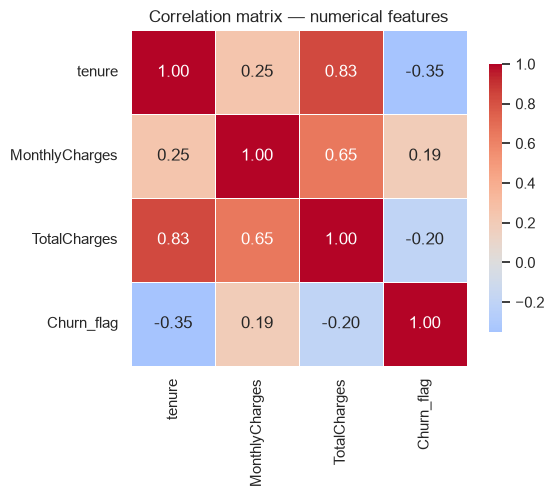


Strongest pairs (by absolute correlation):
tenure          TotalCharges      0.826
MonthlyCharges  TotalCharges      0.651
tenure          Churn_flag       -0.352
                MonthlyCharges    0.248
TotalCharges    Churn_flag       -0.198
MonthlyCharges  Churn_flag        0.193
dtype: float64


In [19]:
# Task 18 — correlation matrix and heatmap
num_df = clean[["tenure", "MonthlyCharges", "TotalCharges"]].copy()

# Encode the target numerically for this view only, so we can see how it relates
# to the numerical features. This is for inspection, not a modelling step.
num_df["Churn_flag"] = (clean["Churn"] == "Yes").astype(int)

corr = num_df.corr(numeric_only=True)
print(corr.round(3))

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation matrix — numerical features")
plt.tight_layout()
plt.show()

# Rank the pairs so the strongest relationships are easy to name
pairs = (corr.where(~np.tril(np.ones(corr.shape)).astype(bool))
             .stack()
             .dropna()
             .sort_values(key=abs, ascending=False))
print("\nStrongest pairs (by absolute correlation):")
print(pairs.round(3))


**Answer 18 (most correlated pairs):**

| Pair | Correlation |
|---|---|
| `tenure` ↔ `TotalCharges` | **+0.826** |
| `MonthlyCharges` ↔ `TotalCharges` | **+0.651** |
| `tenure` ↔ `Churn_flag` | **−0.352** |
| `tenure` ↔ `MonthlyCharges` | +0.248 |
| `TotalCharges` ↔ `Churn_flag` | −0.198 |
| `MonthlyCharges` ↔ `Churn_flag` | +0.193 |

The dominant pair is **`tenure` ↔ `TotalCharges` at 0.826**, and the reason is arithmetic rather than behavioural: `TotalCharges` is essentially `tenure × MonthlyCharges` accumulated over time. I checked this directly — the correlation between `tenure × MonthlyCharges` and `TotalCharges` is **0.9996**, effectively a perfect match. `TotalCharges` is a **derived column**, not an independent measurement.

Among the features, **`tenure` is the strongest predictor of churn (−0.352)**: the longer someone has stayed, the less likely they are to leave.

**Answer 19 (correlation vs. causation; potential problems):**

**No, correlation does not imply causation here.** `tenure` correlates with churn at −0.352, but long tenure does not *cause* loyalty — both are driven by underlying factors like contract type and satisfaction. The direction is arguably reversed: customers stay long *because* they are the type who stays. `TotalCharges` correlating with churn is even less meaningful, since it is just tenure in disguise.

**Yes, these correlations will cause problems for a model.** `tenure` and `TotalCharges` at 0.826 is **multicollinearity**: the two carry nearly the same information, so a linear model cannot decide how to split the credit between them. Coefficients become unstable and can even flip sign, which destroys interpretability — a serious issue when the business wants to know *why* customers leave, not just who. Keeping `TotalCharges` adds almost no new signal beyond what `tenure` and `MonthlyCharges` already provide, so dropping it (or replacing the trio with one derived feature) is worth considering in Lab 3.

---

## Part 9 — Data Leakage Awareness

In Lab 3 you will train a classifier. Before that, you must check whether any column contains information that would not realistically be available at the moment of prediction — using such a column would make a model look artificially accurate.

**Tasks**
20. Inspect the columns for anything that looks like it could only be known after a customer has already churned, or that is purely an identifier. List any suspects and explain your reasoning.
21. In 2–3 sentences, explain what would go wrong if such a column were left in the model's input features.

**Answer 20 (suspect columns and reasoning):**

**1. `customerID` — a pure identifier (definite: remove).**
7,043 unique values across 7,043 rows. It carries no behavioural information whatsoever. A high-capacity model handed this column can memorise individual customers instead of learning a generalisable pattern, producing excellent training scores and useless predictions on anyone new.

**2. `TotalCharges` — a derived, backward-looking column (borderline: use with care).**
This is the genuine leakage-shaped risk in the dataset. `TotalCharges ≈ tenure × MonthlyCharges` (correlation **0.9996**), so it is a *summary of the customer's whole history up to now* rather than an independent fact about them. Two consequences: it duplicates information already in `tenure` and `MonthlyCharges`, and it encodes the outcome window itself — a customer who churned early necessarily has a small `TotalCharges`, so the column partly reflects *how long they stayed*, which is what we are trying to predict.

The 11 blank rows are the clearest evidence of this: they are blank precisely because those customers had not been billed yet, and every one of them is `Churn = No`. The column's own missingness pattern encodes information about the target.

**Not leakage, but worth noting: `gender` is simply useless.** Churn is **26.9% for women and 26.2% for men** — a 0.7 percentage-point gap on 7,043 customers, i.e. noise. It is not dangerous, just dead weight, and it carries fairness risk for no predictive benefit.

**No true post-outcome column exists here** — there is no "cancellation date", "exit reason" or "refund issued" field, which is what hard leakage usually looks like.

**Answer 21 (what would go wrong):**

The model would score extremely well in testing and then fail in production. A leaked column lets the model take a shortcut: instead of learning the behavioural patterns that precede churn, it reads a value that is only knowable *because* the outcome already happened. Validation accuracy looks excellent because the test set contains the same shortcut.

The failure shows up at deployment. For a customer who has **not yet churned**, that column either does not exist, or holds a value that means something completely different from what it meant during training. The model's accuracy collapses exactly when it matters — and worse, the business has already trusted it, so retention budget gets spent on the wrong customers while the real churn risks are missed.

---

## Part 10 — ML-Readiness Checklist

Summarize every column's fate in a single table. This is the bridge between EDA and modeling — Lab 3 will use this table directly.

**Task**
22. Complete the ML-readiness table for **every** column in the dataset.

| Column | Type | Role | Action | Reason |
|---|---|---|---|---|
| `customerID` | Identifier | — | **Remove** | 7,043 unique values across 7,043 rows. No predictive content; invites memorisation instead of learning. |
| `gender` | Categorical (binary) | Feature | Keep, but low value | Churn 26.9% F vs 26.2% M — a 0.7pp gap is noise. Harmless to keep, reasonable to drop. |
| `SeniorCitizen` | Categorical (binary) | Feature | **Keep** — converted 0/1 → No/Yes | Strong signal: 41.7% churn vs 23.6%. Was stored as int; fixed so it is not mistaken for a quantity. |
| `Partner` | Categorical (binary) | Feature | Keep — encode Yes/No → 1/0 | Household context; plausible proxy for stability. |
| `Dependents` | Categorical (binary) | Feature | Keep — encode Yes/No → 1/0 | Same reasoning; customers with dependents move less readily. |
| `tenure` | Numerical (int) | Feature | **Keep** — scale before distance/linear models | Strongest numerical predictor (corr −0.352). Median 38 months for stayers vs 10 for churners. |
| `PhoneService` | Categorical (binary) | Feature | Keep — encode Yes/No → 1/0 | Basic service flag; interacts with `MultipleLines`. |
| `MultipleLines` | Categorical (3-level) | Feature | Keep — one-hot encode | Has a third level `No phone service` that means something different from `No`; do not collapse them. |
| `InternetService` | Categorical (3-level) | Feature | **Keep** — one-hot encode | Very strong signal: Fiber 41.9% vs DSL 19.0% vs None 7.4%. |
| `OnlineSecurity` | Categorical (3-level) | Feature | **Keep** — one-hot encode | Strong signal: 41.8% churn without it vs 14.6% with it. |
| `OnlineBackup` | Categorical (3-level) | Feature | Keep — one-hot encode | Add-on service; same `No internet service` third level. |
| `DeviceProtection` | Categorical (3-level) | Feature | Keep — one-hot encode | Add-on service; same structure. |
| `TechSupport` | Categorical (3-level) | Feature | **Keep** — one-hot encode | Strong signal: 41.6% churn without it vs 15.2% with it. |
| `StreamingTV` | Categorical (3-level) | Feature | Keep — one-hot encode | Add-on service; same structure. |
| `StreamingMovies` | Categorical (3-level) | Feature | Keep — one-hot encode | Add-on service; same structure. |
| `Contract` | Categorical (3-level) | Feature | **Keep** — one-hot encode | Strongest categorical predictor: 42.7% / 11.3% / 2.8%. Ordinal encoding also defensible. |
| `PaperlessBilling` | Categorical (binary) | Feature | Keep — encode Yes/No → 1/0 | Clear signal: 33.6% churn vs 16.3%. |
| `PaymentMethod` | Categorical (4-level) | Feature | **Keep** — one-hot encode | Electronic check churns at 45.3% vs ~15–19% for the rest. |
| `MonthlyCharges` | Numerical (float) | Feature | **Keep** — scale | Churners average 74.44 vs 61.27. Bimodal, no outliers. |
| `TotalCharges` | Numerical (float) | Feature | **Keep with caution** — converted text → numeric, 11 NaN filled with 0.0; consider dropping | Derived: `tenure × MonthlyCharges` correlates 0.9996 with it. Redundant (0.826 with tenure) and multicollinear. |
| `Churn` | Categorical (binary) | **Target** | **Keep** — encode Yes/No → 1/0 | The variable to predict. Imbalanced 73.46% / 26.54%. |

**Summary:** 21 columns in → **1 removed** (`customerID`), **1 target** (`Churn`), **19 features** retained, of which `TotalCharges` is flagged as redundant and `gender` as near-useless.

---

## Part 11 — Building the Clean Dataset

Bring together every cleaning decision into one final dataframe, `clean_df`, that Lab 3 can load directly.

> Do **not** split into train/test, encode categorical variables, or train any model — that happens in Lab 3.

**Tasks**
23. Produce `clean_df` with correct data types, missing values handled, duplicates handled, and irrelevant identifier columns removed where justified. Save it (e.g. `clean_churn.csv`) alongside your notebook.
24. Print `df.info()` (or equivalent) for `clean_df` as final proof that every issue identified earlier has been resolved.

In [20]:
# Task 23 — assemble clean_df from your cleaning decisions
clean_df = clean.copy()

# customerID is a pure identifier: unique per row, carries no signal about behaviour,
# and letting a model see it invites memorisation instead of learning.
clean_df = clean_df.drop(columns=["customerID"])

print("clean_df shape:", clean_df.shape)

clean_df.to_csv("clean_churn.csv", index=False)
print("Saved clean_churn.csv")


clean_df shape: (7043, 20)
Saved clean_churn.csv


In [21]:
# Task 24 — final proof: info() / isnull().sum() / duplicated().sum() on clean_df
clean_df.info()

print("\n--- final checks ---")
print("Total missing values :", int(clean_df.isnull().sum().sum()))
print("Duplicated rows      :", clean_df.duplicated().sum())
print("Numeric columns      :", clean_df.select_dtypes(include=np.number).columns.tolist())
print()
print("Numerical summary:")
print(clean_df.describe().round(2))


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   str    
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

---

## Part 12 — Key Findings & Final Reflection

Step back from the code and summarize what you actually learned about this dataset and this problem.

**Task 25 — Five Important Findings**

**Finding 1 — A "clean" dataset was hiding its only data-quality problem**
- Observation: `isnull()` reported zero missing values in all 21 columns, yet `TotalCharges` was unusable.
- Evidence: 11 rows (0.16%) contained a blank space `" "`, which pandas counts as a present text value. That single blank forced the entire money column to load as text instead of float.
- Interpretation: A missing-value audit that stops at `isnull()` is incomplete. Type mismatches are the more reliable clue — a money column that is not numeric is proof something inside it will not parse, even when the missing-value count says everything is fine.

**Finding 2 — Those 11 rows were not corrupt; they were meaningful**
- Observation: The blank `TotalCharges` rows share an exact pattern rather than being scattered at random.
- Evidence: All 11 have `tenure = 0` and all 11 have `Churn = No`.
- Interpretation: The blank encodes "never billed yet", so **0.0 is the factually correct fill and the median is not** — median imputation would invent roughly \$1,400 of revenue per customer that never existed. Investigating *why* values are missing changed the cleaning decision itself.

**Finding 3 — Contract type is the single strongest driver of churn**
- Observation: Churn rate collapses as contract length increases.
- Evidence: Month-to-month **42.7%**, One year **11.3%**, Two year **2.8%** — a ~15× difference. Month-to-month is also 55% of the customer base, so it produces 1,655 of the 1,869 total churners (**89% of all churn**).
- Interpretation: Both a barrier effect (contracts make leaving costly) and self-selection (uncommitted customers pick flexible plans). Either way, moving customers onto longer contracts is the highest-leverage retention action available.

**Finding 4 — Churn risk is concentrated in the first year, not spread across the lifetime**
- Observation: Churners and stayers have almost entirely different tenure profiles.
- Evidence: Median tenure 38 months (stayed) vs 10 months (churned). Customers in their first 12 months churn at **47.4%**; past 60 months, only **6.6%**. `tenure` has the strongest numerical correlation with churn (−0.352).
- Interpretation: The danger window is onboarding. New customers have no habit and no switching cost; those who pass the first year rarely leave. Retention spend is worth far more early than late.

**Finding 5 — The premium product retains customers worst**
- Observation: Fiber optic — the expensive, fastest tier — churns at more than double the DSL rate.
- Evidence: Fiber optic **41.9%**, DSL **19.0%**, No internet **7.4%**. Consistently, churners pay \$74.44/month on average vs \$61.27 for stayers. Electronic-check payers churn at **45.3%** vs ~15–19% for automatic methods.
- Interpretation: The most valuable customers are the most at risk — the worst possible combination commercially. Price sensitivity, a more competitive market segment, and higher expectations all point the same way. The payment-method result reinforces it: manual payment means a monthly decision to keep paying, while automatic payment removes that moment of reconsideration.

---

**Task 26 — Final Reflection Questions**

1. **What was the most important data-quality issue you found?**
   The 11 blank values in `TotalCharges`. Not because 11 rows out of 7,043 matter statistically, but because they were invisible to `isnull()` and they kept an entire numeric column stuck as text. It was the one issue that would have silently broken every downstream calculation.

2. **What was the most interesting pattern you discovered?**
   That fiber optic — the premium product — has the worst retention (41.9% vs 19.0% for DSL). I expected the opposite. It reframes churn from "cheap customers leave" to "the customers worth the most are the ones most at risk."

3. **Which feature seems most useful for predicting churn?**
   `Contract`, by a clear margin: 42.7% / 11.3% / 2.8% across its three levels, and it accounts for 89% of all churners. `tenure` is the strongest numerical feature (−0.352) and closely related, since both describe commitment.

4. **Which feature should probably not be used, and why?**
   `customerID` must be removed — it is unique per row and lets a model memorise instead of learn. `TotalCharges` is the more interesting case: it correlates 0.9996 with `tenure × MonthlyCharges`, so it adds almost no new information while introducing multicollinearity (0.826 with `tenure`). `gender` is harmless but useless (26.9% vs 26.2%).

5. **What preprocessing will be required before ML modeling (conceptually)?**
   Encode the target `Churn` to 1/0. Binary Yes/No columns can be label-encoded; the multi-level columns (`Contract`, `InternetService`, `PaymentMethod`, and the service add-ons) need one-hot encoding, keeping `No internet service` distinct from `No`. The three numerical columns need scaling for any distance-based or linear model. A train/test split must happen **before** any fitting, and the class imbalance (73.5/26.5) has to be addressed through class weights or resampling — with evaluation on precision/recall/F1 rather than accuracy.

6. **What would you do next if you had another 3 hours?**
   Look at feature *interactions* rather than single features — the month-to-month + fiber optic combination already churns at **54.6%**, far above either factor alone. I would also engineer an `avg_monthly_spend = TotalCharges / tenure` feature to compare against the current `MonthlyCharges` and detect customers whose bill recently rose, and count how many add-on services each customer has as a single "engagement" score, since `OnlineSecurity` and `TechSupport` individually both show ~42% churn when absent.

---

## Bonus Tasks (Optional)

- Create one additional meaningful visualization not required above.
- Investigate a surprising customer subgroup you didn't expect to find.
- Calculate churn rate across a combination of 2+ customer segments at once.
- Identify one possible feature-engineering opportunity for Lab 3.
- Identify one possible source of bias in this dataset.

Churn rate (%) by Contract x InternetService:
Churn                             No   Yes
Contract       InternetService            
Month-to-month DSL              67.8  32.2
               Fiber optic      45.4  54.6
               No               81.1  18.9
One year       DSL              90.7   9.3
               Fiber optic      80.7  19.3
               No               97.5   2.5
Two year       DSL              98.1   1.9
               Fiber optic      92.8   7.2
               No               99.2   0.8

Group sizes (read the percentages above with these in mind):
Contract        InternetService
Month-to-month  DSL                1223
                Fiber optic        2128
                No                  524
One year        DSL                 570
                Fiber optic         539
                No                  364
Two year        DSL                 628
                Fiber optic         429
                No                  638
dtype: int64


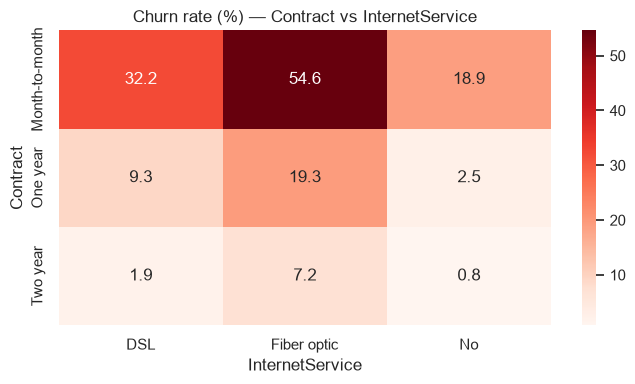

In [22]:
# Bonus — optional exploration
# Churn rate across TWO segments at once: contract type x internet service.
combo = (pd.crosstab([clean["Contract"], clean["InternetService"]],
                     clean["Churn"], normalize="index") * 100).round(1)
print("Churn rate (%) by Contract x InternetService:")
print(combo)

sizes = pd.crosstab([clean["Contract"], clean["InternetService"]], clean["Churn"]).sum(axis=1)
print("\nGroup sizes (read the percentages above with these in mind):")
print(sizes)

pivot = (pd.crosstab(clean["Contract"], clean["InternetService"],
                     values=(clean["Churn"] == "Yes").astype(int), aggfunc="mean") * 100)
plt.figure(figsize=(7, 4))
sns.heatmap(pivot.round(1), annot=True, fmt=".1f", cmap="Reds")
plt.title("Churn rate (%) — Contract vs InternetService")
plt.tight_layout()
plt.show()


---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Completed all 26 tasks above, with written interpretation for every chart and decision
- [ ] A working `clean_df`, saved as `clean_churn.csv`
- [ ] A completed ML-readiness table (Part 10) covering every column
- [ ] Five Key Findings written (Part 12)
- [ ] Answered all six Final Reflection questions
- [ ] Committed and pushed this notebook + `clean_churn.csv` to your GitHub repository
- [ ] Added your GitHub repository link at the top of this notebook